# Ablation Study — KD Temperature $T$ (and, optionally, $\lambda$)

Rubric requirement: *"at least one meaningful ablation on T, λ, or Δ"*. This notebook sweeps $T$ with every other hyperparameter held fixed at the values in `StudentKDQATConfig`, training a fresh student from scratch for each value.

**Hypothesis:** very low $T$ (≈1) gives the student almost no extra information beyond the hard labels (the teacher's softmax is already close to one-hot), so KD should behave similarly to plain supervised training. Very high $T$ over-smooths the teacher's distribution, potentially washing out genuinely useful class-similarity information. A moderate $T$ (commonly 2–8 in the KD literature) is expected to work best — but this must be checked empirically here, not assumed.

**Note on compute budget:** ablation runs use `AblationConfig.ablation_epochs` (fewer epochs than the final full training run in Notebook 03) — a standard, explicit trade-off for *relative* comparison across settings under limited compute. State this in your report; do not treat these as your best final numbers.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
from src.utils import set_seed, get_device, plot_training_curves

set_seed(42)
device = get_device()
print("Using device:", device)


Using device: cuda


In [2]:
from src.data import get_cifar10_loaders

train_loader, val_loader, test_loader = get_cifar10_loaders(
    data_dir="../data", batch_size=128, val_fraction=0.1, num_workers=2, seed=42
)


In [3]:
from src.resnet_cifar import resnet34_cifar, resnet18_cifar
from src.ternary import TernaryConv2d, TernaryLinear
from src.config import StudentKDQATConfig, AblationConfig

teacher = resnet34_cifar(num_classes=10)
teacher_ckpt = torch.load(StudentKDQATConfig().teacher_checkpoint, map_location=device)
teacher.load_state_dict(teacher_ckpt["model_state_dict"])
teacher.to(device)
teacher.eval()
for p in teacher.parameters():
    p.requires_grad_(False)

def student_factory():
    return resnet18_cifar(num_classes=10, conv_layer=TernaryConv2d,
                           linear_layer=TernaryLinear, first_last_fp32=True)

ablation_cfg = AblationConfig()
print("Temperature values to sweep:", ablation_cfg.temperature_values)
print("Ablation epochs per run:", ablation_cfg.ablation_epochs)


Temperature values to sweep: [1.0, 2.0, 4.0, 8.0]
Ablation epochs per run: 40


## Run the temperature ablation
$\lambda$ (`kd_alpha`) is held fixed at the default from `StudentKDQATConfig` while $T$ varies.

In [7]:
from src.kd_loss import KDLoss
from src.ablation import run_ablation

base_cfg = StudentKDQATConfig(epochs=100)          
base_cfg.checkpoint_path = "checkpoints/ablation_temperature_student.pth"

def kd_loss_factory(cfg):
    return KDLoss(temperature=cfg.temperature, alpha=cfg.kd_alpha,
                   label_smoothing=cfg.label_smoothing)

temperature_results = run_ablation(
    student_factory, teacher, train_loader, val_loader, device,
    base_cfg, kd_loss_factory,
    param_name="temperature", param_values=ablation_cfg.temperature_values,
)
temperature_results.to_csv("results/ablation_temperature.csv", index=False)
temperature_results


=== Ablation: temperature = 1.0 ===
Epoch   1/100 | quant=OFF (warmup) | train_loss 1.4560 (kd 1.3474, hard 1.7092) acc 38.95% | val_loss 2.3228 acc 17.20%
Epoch   2/100 | quant=OFF (warmup) | train_loss 0.9656 (kd 0.8881, hard 1.1464) acc 59.66% | val_loss 2.4075 acc 20.48%
Epoch   3/100 | quant=OFF (warmup) | train_loss 0.7500 (kd 0.6878, hard 0.8952) acc 69.68% | val_loss 2.1717 acc 27.04%
Epoch   4/100 | quant=OFF (warmup) | train_loss 0.6197 (kd 0.5659, hard 0.7453) acc 75.54% | val_loss 2.1495 acc 25.70%
Epoch   5/100 | quant=OFF (warmup) | train_loss 0.5306 (kd 0.4821, hard 0.6436) acc 79.22% | val_loss 2.8771 acc 11.72%
Epoch   6/100 | quant=ON | train_loss 0.5258 (kd 0.4768, hard 0.6403) acc 79.42% | val_loss 0.5435 acc 78.08%
Epoch   7/100 | quant=ON | train_loss 0.4705 (kd 0.4245, hard 0.5777) acc 81.79% | val_loss 0.4972 acc 79.42%
Epoch   8/100 | quant=ON | train_loss 0.4381 (kd 0.3940, hard 0.5412) acc 82.96% | val_loss 0.4636 acc 80.76%
Epoch   9/100 | quant=ON | train_

Epoch  75/100 | quant=ON | train_loss 0.0767 (kd 0.0553, hard 0.1265) acc 97.99% | val_loss 0.2008 acc 92.24%
Epoch  76/100 | quant=ON | train_loss 0.0660 (kd 0.0453, hard 0.1143) acc 98.42% | val_loss 0.2101 acc 92.04%
Epoch  77/100 | quant=ON | train_loss 0.0641 (kd 0.0435, hard 0.1124) acc 98.56% | val_loss 0.2246 acc 91.32%
Epoch  78/100 | quant=ON | train_loss 0.0621 (kd 0.0415, hard 0.1103) acc 98.57% | val_loss 0.1809 acc 92.82%
Epoch  79/100 | quant=ON | train_loss 0.0554 (kd 0.0354, hard 0.1022) acc 98.86% | val_loss 0.1762 acc 93.32%
Epoch  80/100 | quant=ON | train_loss 0.0520 (kd 0.0320, hard 0.0988) acc 98.97% | val_loss 0.1712 acc 93.54%
Epoch  81/100 | quant=ON | train_loss 0.0466 (kd 0.0269, hard 0.0924) acc 99.25% | val_loss 0.1776 acc 93.54%
Epoch  82/100 | quant=ON | train_loss 0.0419 (kd 0.0225, hard 0.0872) acc 99.38% | val_loss 0.1784 acc 93.44%
Epoch  83/100 | quant=ON | train_loss 0.0399 (kd 0.0206, hard 0.0850) acc 99.48% | val_loss 0.1593 acc 93.98%
Epoch  84/

Epoch  49/100 | quant=ON | train_loss 0.2630 (kd 0.2410, hard 0.3145) acc 92.19% | val_loss 0.3627 acc 86.98%
Epoch  50/100 | quant=ON | train_loss 0.2545 (kd 0.2323, hard 0.3061) acc 92.38% | val_loss 0.3132 acc 88.88%
Epoch  51/100 | quant=ON | train_loss 0.2532 (kd 0.2312, hard 0.3047) acc 92.43% | val_loss 0.4012 acc 86.06%
Epoch  52/100 | quant=ON | train_loss 0.2492 (kd 0.2269, hard 0.3012) acc 92.64% | val_loss 0.4217 acc 85.80%
Epoch  53/100 | quant=ON | train_loss 0.2381 (kd 0.2161, hard 0.2895) acc 92.93% | val_loss 0.3734 acc 87.02%
Epoch  54/100 | quant=ON | train_loss 0.2333 (kd 0.2109, hard 0.2856) acc 93.16% | val_loss 0.2879 acc 89.72%
Epoch  55/100 | quant=ON | train_loss 0.2268 (kd 0.2044, hard 0.2788) acc 93.41% | val_loss 0.3178 acc 88.18%
Epoch  56/100 | quant=ON | train_loss 0.2267 (kd 0.2045, hard 0.2785) acc 93.26% | val_loss 0.2956 acc 89.54%
Epoch  57/100 | quant=ON | train_loss 0.2171 (kd 0.1948, hard 0.2692) acc 93.80% | val_loss 0.2951 acc 89.52%
Epoch  58/

Epoch  23/100 | quant=ON | train_loss 0.3383 (kd 0.2900, hard 0.4510) acc 87.87% | val_loss 0.4933 acc 79.68%
Epoch  24/100 | quant=ON | train_loss 0.3342 (kd 0.2863, hard 0.4460) acc 88.11% | val_loss 0.4581 acc 82.14%
Epoch  25/100 | quant=ON | train_loss 0.3311 (kd 0.2835, hard 0.4422) acc 88.11% | val_loss 0.3895 acc 84.08%
Epoch  26/100 | quant=ON | train_loss 0.3248 (kd 0.2779, hard 0.4341) acc 88.33% | val_loss 0.4156 acc 83.82%
Epoch  27/100 | quant=ON | train_loss 0.3218 (kd 0.2749, hard 0.4313) acc 88.58% | val_loss 0.4299 acc 82.22%
Epoch  28/100 | quant=ON | train_loss 0.3160 (kd 0.2698, hard 0.4237) acc 88.76% | val_loss 0.3691 acc 84.96%
Epoch  29/100 | quant=ON | train_loss 0.3125 (kd 0.2666, hard 0.4196) acc 89.02% | val_loss 0.3699 acc 85.30%
Epoch  30/100 | quant=ON | train_loss 0.3090 (kd 0.2635, hard 0.4152) acc 88.95% | val_loss 0.4139 acc 83.60%
Epoch  31/100 | quant=ON | train_loss 0.3075 (kd 0.2620, hard 0.4138) acc 89.11% | val_loss 0.3733 acc 84.50%
Epoch  32/

Epoch  98/100 | quant=ON | train_loss 0.0317 (kd 0.0083, hard 0.0862) acc 99.94% | val_loss 0.1372 acc 94.78%
Epoch  99/100 | quant=ON | train_loss 0.0315 (kd 0.0081, hard 0.0860) acc 99.92% | val_loss 0.1376 acc 94.76%
Epoch 100/100 | quant=ON | train_loss 0.0311 (kd 0.0079, hard 0.0853) acc 99.96% | val_loss 0.1390 acc 94.76%

=== Ablation: temperature = 8.0 ===
Epoch   1/100 | quant=OFF (warmup) | train_loss 1.1982 (kd 0.9971, hard 1.6674) acc 42.20% | val_loss 1.6967 acc 16.26%
Epoch   2/100 | quant=OFF (warmup) | train_loss 0.7999 (kd 0.6611, hard 1.1236) acc 63.66% | val_loss 1.7727 acc 16.00%
Epoch   3/100 | quant=OFF (warmup) | train_loss 0.6388 (kd 0.5255, hard 0.9032) acc 72.19% | val_loss 1.7432 acc 11.10%
Epoch   4/100 | quant=OFF (warmup) | train_loss 0.5401 (kd 0.4416, hard 0.7699) acc 76.94% | val_loss 1.6261 acc 16.92%
Epoch   5/100 | quant=OFF (warmup) | train_loss 0.4884 (kd 0.3962, hard 0.7035) acc 79.45% | val_loss 1.6224 acc 22.16%
Epoch   6/100 | quant=ON | train_

Epoch  72/100 | quant=ON | train_loss 0.1043 (kd 0.0713, hard 0.1813) acc 96.86% | val_loss 0.1912 acc 91.86%
Epoch  73/100 | quant=ON | train_loss 0.0978 (kd 0.0660, hard 0.1720) acc 97.12% | val_loss 0.2191 acc 91.04%
Epoch  74/100 | quant=ON | train_loss 0.0941 (kd 0.0629, hard 0.1671) acc 97.30% | val_loss 0.2061 acc 91.44%
Epoch  75/100 | quant=ON | train_loss 0.0875 (kd 0.0572, hard 0.1584) acc 97.64% | val_loss 0.1967 acc 91.96%
Epoch  76/100 | quant=ON | train_loss 0.0820 (kd 0.0526, hard 0.1507) acc 97.77% | val_loss 0.1741 acc 92.68%
Epoch  77/100 | quant=ON | train_loss 0.0774 (kd 0.0487, hard 0.1445) acc 97.95% | val_loss 0.1749 acc 92.44%
Epoch  78/100 | quant=ON | train_loss 0.0727 (kd 0.0446, hard 0.1381) acc 98.19% | val_loss 0.1778 acc 92.42%
Epoch  79/100 | quant=ON | train_loss 0.0682 (kd 0.0409, hard 0.1319) acc 98.44% | val_loss 0.1687 acc 92.98%
Epoch  80/100 | quant=ON | train_loss 0.0599 (kd 0.0339, hard 0.1206) acc 98.70% | val_loss 0.1753 acc 92.90%
Epoch  81/

,temperature,best_val_acc,final_train_acc,final_kd_term,final_hard_term,checkpoint
0,1.0,94.88,99.96,0.0081,0.0707,checkpoints/ablation_temperature_student_tempe...
1,2.0,94.80,99.94,0.0078,0.0883,checkpoints/ablation_temperature_student_tempe...
2,4.0,94.92,99.96,0.0079,0.0853,checkpoints/ablation_temperature_student_tempe...
3,8.0,94.72,99.93,0.0086,0.0825,checkpoints/ablation_temperature_student_tempe...


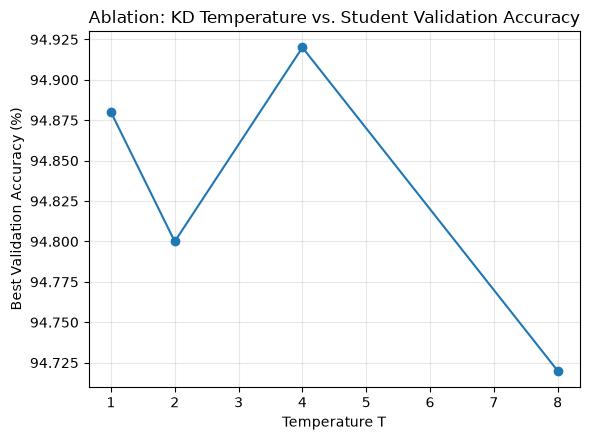

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4.5))
plt.plot(temperature_results["temperature"], temperature_results["best_val_acc"], marker="o")
plt.xlabel("Temperature T")
plt.ylabel("Best Validation Accuracy (%)")
plt.title("Ablation: KD Temperature vs. Student Validation Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/ablation_temperature_plot.png", dpi=150, bbox_inches="tight")
plt.show()
